# Gold: sentimento (`governor_sentiment`)

ADR [0022](../../docs/adr/0022-notebooks-de-diagnostico-medallion-separados-da-narrativa-do-tcc.md)
(issue [#128](https://github.com/Vini0606/Tecnicas-de-Ciencia-de-Dados-em-dados-do-Instagram/issues/128)).
Diagnóstico de `governor_sentiment` (+ `governor_sentiment_history`) -- saída de
`src/modeling/sentiment.py`, granularidade de **um comentário por linha**, não um governador por
linha. Notebook estritamente leitura via `DeltaRepository`, mesmo princípio da ADR
[0003](../../docs/adr/0003-desacoplar-modelagem-do-notebook-via-scripts-cli-com-checkpoint.md).

In [1]:
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

from config import settings
from src.repositories.delta_repository import DeltaRepository
from src.visualization.charts import plot_sentiment_diverging_bar, plot_sentiment_trend
from src.analysis.medallion_diagnostics import (
    completeness_summary,
    count_duplicate_rows,
    with_governor_metadata,
)

load_dotenv()
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', None)

repo = DeltaRepository(gold_dir=settings.GOLD_DIR, silver_dir=settings.SILVER_DIR)

## 1. Carga + schema

`DeltaRepository.load_comments()` tenta `governor_sentiment` (Gold) e só cai para
`comments_clean` (Silver, sem `sentiment_label`) se a modelagem ainda não rodou -- checagem
explícita abaixo em vez de deixar o `KeyError` estourar mais adiante sem contexto.

In [2]:
df_sentiment = repo.load_comments()
if 'sentiment_label' not in df_sentiment.columns:
    raise RuntimeError(
        'governor_sentiment sem sentiment_label -- a etapa de modelagem determinística '
        '(run_deterministic_modeling / pipeline.py --run-modeling) ainda não rodou. '
        'Este notebook precisa da saída de modelo, não só de comments_clean (Silver).'
    )
df_sentiment.dtypes

id_reel                         object
id_comment                      object
text                            object
inputUrl                        object
ownerUsername                   object
likesCount                       int64
repliesCount                   float64
timestamp                       object
fonte                           object
sentiment_label                 object
sentiment_score                float64
Topic                          float64
Name                            object
_run_id                         object
_generated_at      datetime64[us, UTC]
dtype: object

## 2. Completude

Granularidade de comentário -- duplicata é checada por `id_comment`, não pela linha inteira.

In [3]:
completude = completeness_summary(df_sentiment)
print(f"linhas duplicadas (por id_comment): {count_duplicate_rows(df_sentiment, subset=['id_comment'])}")
completude[completude['n_nulos'] > 0]

linhas duplicadas (por id_comment): 693


,coluna,dtype,n_nulos,pct_nulos,n_unicos
1,id_comment,object,694,16.2605,3574
2,text,object,277,6.4902,2838
6,repliesCount,float64,4268,100.0000,0
9,sentiment_label,object,332,7.7788,3
10,sentiment_score,float64,332,7.7788,2830
11,Topic,float64,694,16.2605,50
12,Name,object,694,16.2605,50


## 3. Distribuição de sentimento

Reaproveita `plot_sentiment_diverging_bar` de `src/visualization/charts.py` (já testada, mesmo
gráfico usado no dashboard) + distribuição de `sentiment_score`.

In [4]:
plot_sentiment_diverging_bar(df_sentiment, title='Distribuição de sentimento -- todos os comentários')

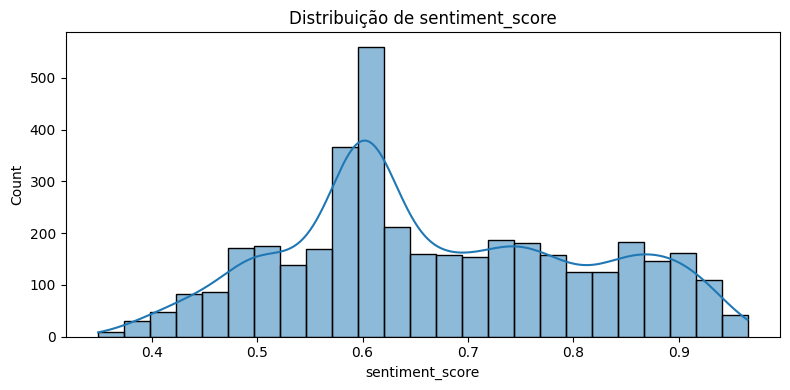

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df_sentiment['sentiment_score'], kde=True, ax=ax)
ax.set_title('Distribuição de sentiment_score')
plt.tight_layout()
plt.show()

## 4. Evolução temporal (`governor_sentiment_history`)

`plot_sentiment_trend` espera dado já filtrado para **um** governador (ver docstring em
`charts.py`) -- é uma tendência narrativa por perfil, não comparação entre pares. Usamos aqui o
governador com mais comentários acumulados como exemplo; trocar `governador_exemplo` reaplica a
mesma seção para qualquer outro.

In [6]:
df_sentiment_history = repo.load_sentiment_history()
governador_exemplo = df_sentiment_history['ownerUsername'].value_counts().idxmax()
df_exemplo = df_sentiment_history[df_sentiment_history['ownerUsername'] == governador_exemplo]

print(f"{df_sentiment_history['_run_id'].nunique()} execuções acumuladas; exemplo: {governador_exemplo}")
fig = plot_sentiment_trend(df_exemplo, title=f'% Positivo -- {governador_exemplo}')
fig

2 execuções acumuladas; exemplo: elmanofreitas


## 5. Relação com covariáveis (partido/UF)

`% positivo` por partido, agregado sobre todos os comentários do partido (não por governador
individual).

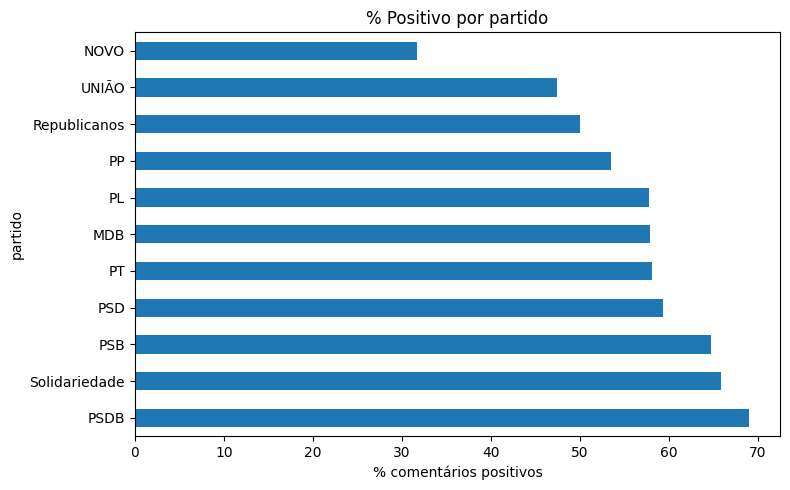

In [7]:
df_com_metadado = with_governor_metadata(df_sentiment, repo.load_governors_metadata())
positivo_por_partido = (
    df_com_metadado.assign(_positivo=df_com_metadado['sentiment_label'] == 'positive')
    .groupby('partido')['_positivo']
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 5))
positivo_por_partido.plot(kind='barh', ax=ax)
ax.set_xlabel('% comentários positivos')
ax.set_title('% Positivo por partido')
plt.tight_layout()
plt.show()

## 6. Outliers

Governadores cuja `% positivo` está a mais de 2 desvios-padrão da média entre perfis -- sinalizados
por perfil, não por comentário individual (um comentário isolado extremo não é o que importa aqui).

In [8]:
positivo_por_governador = (
    df_sentiment.assign(_positivo=df_sentiment['sentiment_label'] == 'positive')
    .groupby('ownerUsername')['_positivo']
    .mean()
    .mul(100)
)
media = positivo_por_governador.mean()
desvio = positivo_por_governador.std()
outliers = positivo_por_governador[(positivo_por_governador - media).abs() > 2 * desvio]
print(f'{len(outliers)} perfis fora de 2 desvios-padrão em % positivo (média={media:.2f}, desvio={desvio:.2f})')
outliers.sort_values(ascending=False)

0 perfis fora de 2 desvios-padrão em % positivo (média=61.77, desvio=47.10)


Series([], Name: _positivo, dtype: float64)

## Nota de interpretação

`% positivo` por perfil é sensível ao volume de comentários (perfis com poucos comentários têm
proporção mais instável) -- cruzar `outliers` acima com a contagem de comentários por perfil antes
de tratar um extremo como um padrão real de recepção do público.